In [19]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt
import seaborn as sns


print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("All good — ready to build!")

pandas: 3.0.1
numpy: 2.4.3
scipy: 1.17.1
statsmodels: 0.14.6
All good — ready to build!


In [6]:
# Load the dataset
df = pd.read_csv('/Users/jeffrey/nba_ab_test/data/nba_notifications_experiment.csv')
print(df.shape)
df.head()

(10000, 8)


,user_id,group,platform,user_tenure_days,games_watched_30d,favorite_team_playing,clicked,session_duration_sec
0,0,control,iOS,235,9,False,0,182
1,1,treatment,iOS,36,6,True,0,219
2,2,treatment,iOS,76,6,False,0,139
3,3,treatment,Android,195,6,False,0,223
4,4,control,iOS,118,7,False,0,214


In [7]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect = proportion_effectsize(0.18, 0.20)  # baseline vs. expected lift
analysis = NormalIndPower()
n = analysis.solve_power(effect_size=effect, alpha=0.05, power=0.80)
print(f"Required sample per group: {int(np.ceil(n))}")

Required sample per group: 6036


## Sanity Checks

In [11]:
# Check sample ratio mismatch (SRM) — critical real-world step
group_counts = df['group'].value_counts()
chi2, p = stats.chisquare(group_counts)
print(f"SRM check — chi2: {chi2:.4f}, p-value: {p:.4f}")
# p > 0.05 means groups are balanced 

# Check pre-experiment covariate balance
print(df.groupby('group')[['user_tenure_days', 'games_watched_30d']].mean())

SRM check — chi2: 2.3104, p-value: 0.1285
           user_tenure_days  games_watched_30d
group                                         
control          179.714933           5.970449
treatment        177.917953           6.009748


## Primary Test - Two-Proportion Z-test

In [12]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

counts = np.array([treatment['clicked'].sum(), control['clicked'].sum()])
nobs = np.array([len(treatment), len(control)])

z, p = proportions_ztest(counts, nobs)
ctrl_ctr = control['clicked'].mean()
treat_ctr = treatment['clicked'].mean()
relative_lift = (treat_ctr - ctrl_ctr) / ctrl_ctr * 100

print(f"Control CTR:   {ctrl_ctr:.2%}")
print(f"Treatment CTR: {treat_ctr:.2%}")
print(f"Relative lift: {relative_lift:.1f}%")
print(f"Z-stat: {z:.3f}, p-value: {p:.4f}")

Control CTR:   18.10%
Treatment CTR: 24.51%
Relative lift: 35.4%
Z-stat: 7.830, p-value: 0.0000


## Confidence Interval

In [15]:
from statsmodels.stats.proportion import proportion_confint

ci_low, ci_high = proportion_confint(
    treatment['clicked'].sum(), len(treatment), alpha=0.05, method='wilson')
print(f"95% CI for treatment CTR: [{ci_low:.2%}, {ci_high:.2%}]")

95% CI for treatment CTR: [23.33%, 25.73%]


## Segment Analaysis
dividing a broad target market or customer base into smaller, homogeneous subgroups based on shared characteristics like demographics, behaviors, psychographics, or geography

In [16]:
# Does the effect hold across segments?
for segment, group_data in df.groupby('favorite_team_playing'):
    c = group_data[group_data['group']=='control']['clicked'].mean()
    t = group_data[group_data['group']=='treatment']['clicked'].mean()
    print(f"Favorite team playing={segment}: Control={c:.2%}, Treatment={t:.2%}")

# Platform breakdown
for platform, group_data in df.groupby('platform'):
    c = group_data[group_data['group']=='control']['clicked'].mean()
    t = group_data[group_data['group']=='treatment']['clicked'].mean()
    print(f"Platform={platform}: Control={c:.2%}, Treatment={t:.2%}")

Favorite team playing=False: Control=18.02%, Treatment=23.83%
Favorite team playing=True: Control=18.27%, Treatment=25.72%
Platform=Android: Control=18.09%, Treatment=24.26%
Platform=iOS: Control=18.11%, Treatment=24.68%


## Secondary Metric — Session Duration (t-test)

In [17]:
t_stat, p_val = stats.ttest_ind(
    treatment[treatment['clicked']==1]['session_duration_sec'],
    control[control['clicked']==1]['session_duration_sec']
)
print(f"Session duration t-test: t={t_stat:.3f}, p={p_val:.4f}")

Session duration t-test: t=-0.515, p=0.6066


## Visualizations

In [21]:
# Set visual style

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
colors = {'control': '#4C72B0', 'treatment': '#DD8452'}

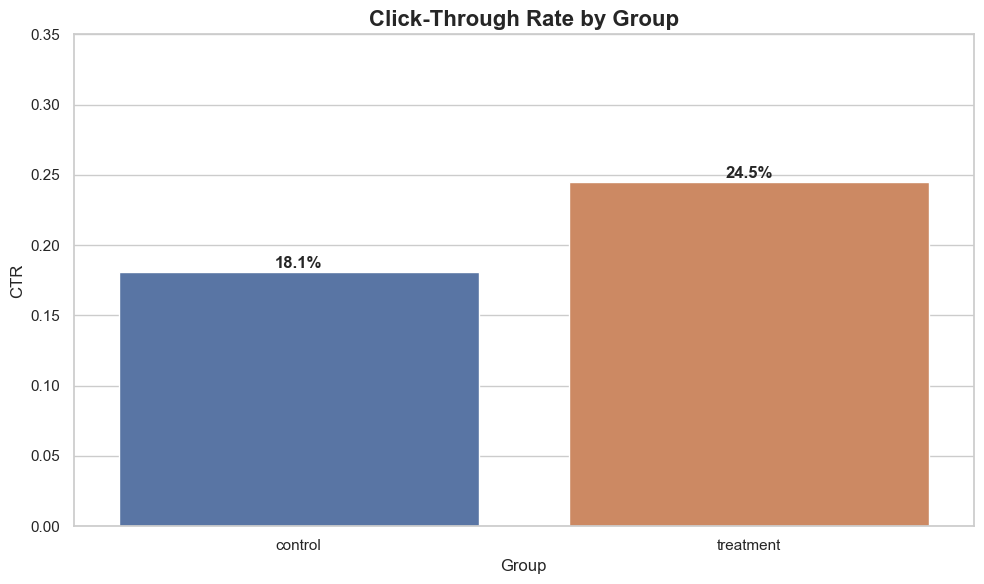

In [35]:
ctr_by_group = df.groupby('group')['clicked'].mean().reset_index()
ctr_by_group.columns = ['group', 'ctr']

plt.figure()
bars = sns.barplot(data=ctr_by_group, x='group', y='ctr', 
                   hue='group', palette=colors, legend=False)

# Add value labels on bars
for bar, val in zip(bars.patches, ctr_by_group['ctr']):
    bars.text(bar.get_x() + bar.get_width()/2, 
              bar.get_height() + 0.003, 
              f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.title('Click-Through Rate by Group', fontsize=16, fontweight='bold')
plt.xlabel('Group', fontsize=12)
plt.ylabel('CTR', fontsize=12)
plt.ylim(0, 0.35)
plt.tight_layout()
plt.savefig('/Users/jeffrey/nba_ab_test/dashboard/ctr_by_group.png', dpi=150)
plt.show()

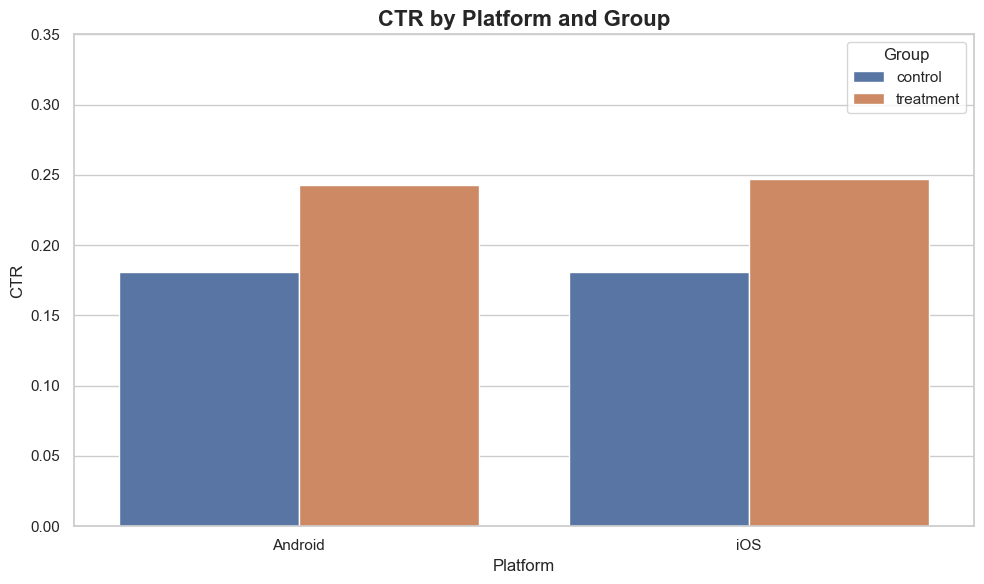

In [38]:
ctr_platform = df.groupby(['platform', 'group'])['clicked'].mean().reset_index()

plt.figure()
sns.barplot(data=ctr_platform, x='platform', y='clicked', hue='group', palette=colors)

plt.title('CTR by Platform and Group', fontsize=16, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('CTR', fontsize=12)
plt.legend(title='Group')
plt.ylim(0, 0.35)
plt.tight_layout()
plt.savefig('/Users/jeffrey/nba_ab_test/dashboard/ctr_by_platform.png',dpi=150)
plt.show()

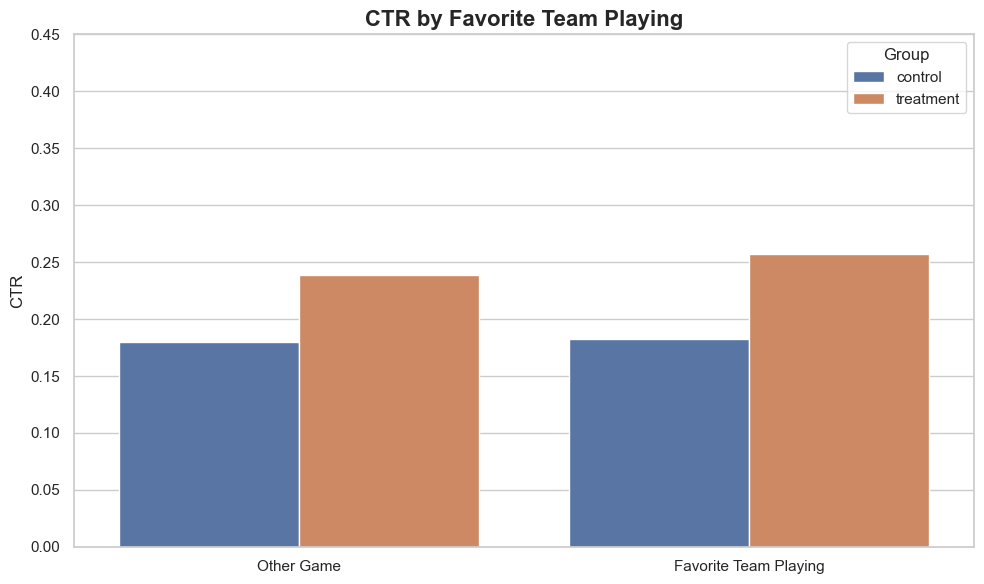

In [39]:
ctr_team = df.groupby(['favorite_team_playing', 'group'])['clicked'].mean().reset_index()
ctr_team['favorite_team_playing'] = ctr_team['favorite_team_playing'].map(
    {True: 'Favorite Team Playing', False: 'Other Game'})

plt.figure()
sns.barplot(data=ctr_team, x='favorite_team_playing', y='clicked', hue='group', palette=colors)

plt.title('CTR by Favorite Team Playing', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('CTR', fontsize=12)
plt.legend(title='Group')
plt.ylim(0, 0.45)
plt.tight_layout()
plt.savefig('/Users/jeffrey/nba_ab_test/dashboard/ctr_by_team.png', dpi=150)
plt.show()

# Session Duration Distribution (Box Plot)

/var/folders/y_/76dg4jt963q9_15119cpy4qh0000gn/T/ipykernel_93454/1901403487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clicked_users, x='group', y='session_duration_sec', palette=colors)


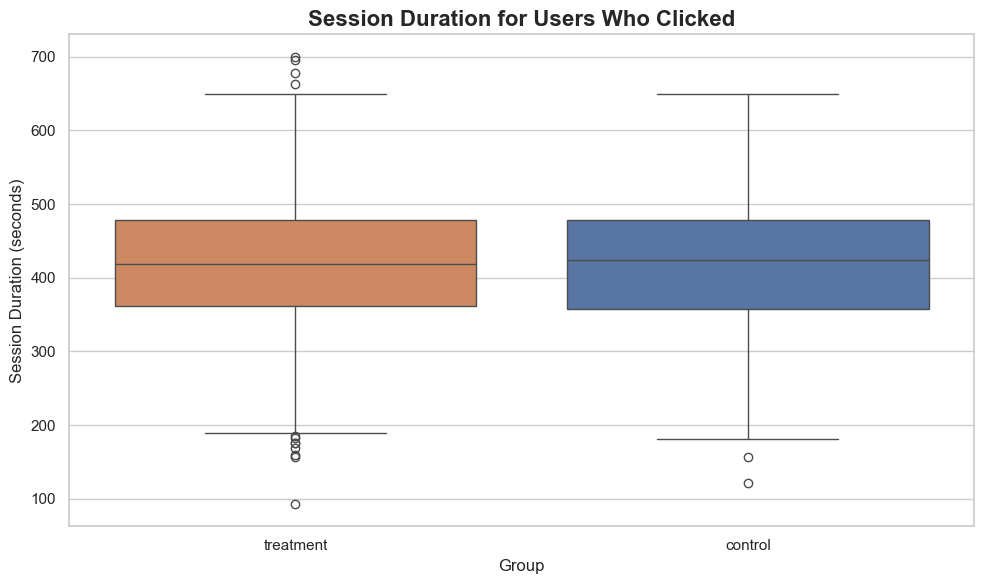

In [40]:
clicked_users = df[df['clicked'] == 1]

plt.figure()
sns.boxplot(data=clicked_users, x='group', y='session_duration_sec', palette=colors)

plt.title('Session Duration for Users Who Clicked', fontsize=16, fontweight='bold')
plt.xlabel('Group', fontsize=12)
plt.ylabel('Session Duration (seconds)', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/jeffrey/nba_ab_test/dashboard/session_duration.png', dpi=150)
plt.show()

# Engagement Tier Heatmap

Tableau CSV exported successfully!


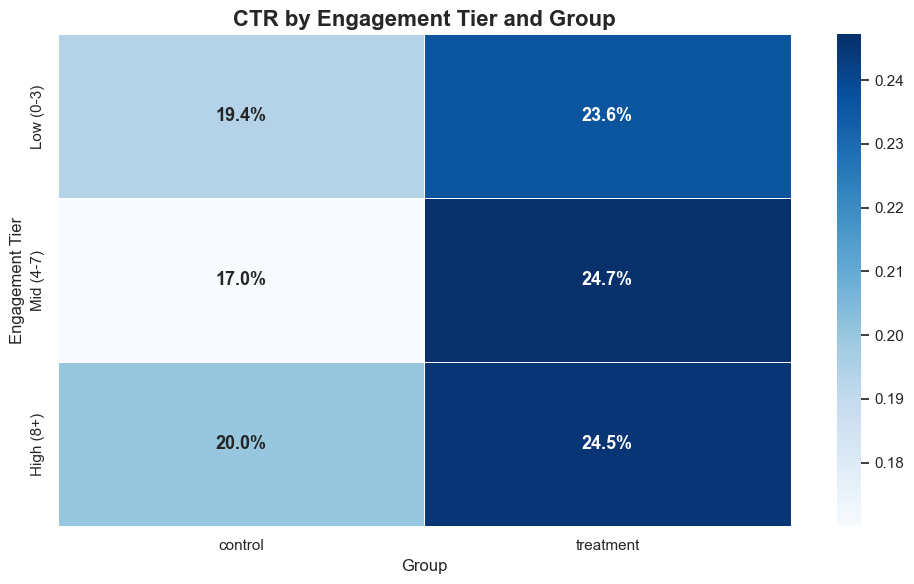

In [42]:
# Create engagement tier based on games watched
df['engagement_tier'] = pd.cut(df['games_watched_30d'], 
    bins=[0, 3, 7, 100], 
    labels=['Low (0-3)', 'Mid (4-7)', 'High (8+)'])

df.to_csv('/Users/jeffrey/nba_ab_test/data/nba_notifications_tableau.csv', index=False)
print("Tableau CSV exported successfully!")

heatmap_data = df.groupby(['engagement_tier', 'group'])['clicked'].mean().unstack()

plt.figure()
sns.heatmap(heatmap_data, annot=True, fmt='.1%', 
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 13, 'weight': 'bold'})

plt.title('CTR by Engagement Tier and Group', fontsize=16, fontweight='bold')
plt.xlabel('Group', fontsize=12)
plt.ylabel('Engagement Tier', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/jeffrey/nba_ab_test/dashboard/engagement_heatmap.png', dpi=150)
plt.show()

In [44]:
df_check = pd.read_csv('/Users/jeffrey/nba_ab_test/data/nba_notifications_tableau.csv')
print(df_check.shape)  # should print (10000, 9)

(10000, 9)


# Summary Stats Table

In [32]:
summary = df.groupby('group').agg(
    users=('user_id', 'count'),
    clicks=('clicked', 'sum'),
    ctr=('clicked', 'mean'),
    avg_session_sec=('session_duration_sec', 'mean')
).round(4)

summary['ctr'] = summary['ctr'].map('{:.2%}'.format)
summary['avg_session_sec'] = summary['avg_session_sec'].map('{:.1f}'.format)
print(summary)

           users  clicks     ctr avg_session_sec
group                                           
control     5076     919  18.10%           223.2
treatment   4924    1207  24.51%           239.9


In [33]:
import os
os.getcwd()

'/Users/jeffrey/nba_ab_test'